In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


# 1) Завантаження та первинний аналіз даних: завантажити датасет; вивести назви колонок та розмір датасета; визначити ознаки (features) та цільову змінну (target); перевірити типи даних та розподіл об'єктів за класами.
1. Завантажити датасет;
2. Вивести назви колонок та розмір датасета;
3. Визначити ознаки (features) та цільову змінну (target);
4. Перевірити типи даних та розподіл об'єктів за класами

## Завантажити датасет

In [2]:
path = Path("data/Date_Fruit_Datasets.xlsx")
raw_data = pd.read_excel(path)

## Вивести назви колонок та розмір датасета

In [3]:
rows, cols = raw_data.shape

print(f"Columns names: {raw_data.columns.tolist()}")
print(f"Dataset size: {rows} rows x {cols} cols = {raw_data.size}")

Columns names: ['AREA', 'PERIMETER', 'MAJOR_AXIS', 'MINOR_AXIS', 'ECCENTRICITY', 'EQDIASQ', 'SOLIDITY', 'CONVEX_AREA', 'EXTENT', 'ASPECT_RATIO', 'ROUNDNESS', 'COMPACTNESS', 'SHAPEFACTOR_1', 'SHAPEFACTOR_2', 'SHAPEFACTOR_3', 'SHAPEFACTOR_4', 'MeanRR', 'MeanRG', 'MeanRB', 'StdDevRR', 'StdDevRG', 'StdDevRB', 'SkewRR', 'SkewRG', 'SkewRB', 'KurtosisRR', 'KurtosisRG', 'KurtosisRB', 'EntropyRR', 'EntropyRG', 'EntropyRB', 'ALLdaub4RR', 'ALLdaub4RG', 'ALLdaub4RB', 'Class']
Dataset size: 898 rows x 35 cols = 31430


## Визначити ознаки (features) та цільову змінну (target)

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AREA           898 non-null    int64  
 1   PERIMETER      898 non-null    float64
 2   MAJOR_AXIS     898 non-null    float64
 3   MINOR_AXIS     898 non-null    float64
 4   ECCENTRICITY   898 non-null    float64
 5   EQDIASQ        898 non-null    float64
 6   SOLIDITY       898 non-null    float64
 7   CONVEX_AREA    898 non-null    int64  
 8   EXTENT         898 non-null    float64
 9   ASPECT_RATIO   898 non-null    float64
 10  ROUNDNESS      898 non-null    float64
 11  COMPACTNESS    898 non-null    float64
 12  SHAPEFACTOR_1  898 non-null    float64
 13  SHAPEFACTOR_2  898 non-null    float64
 14  SHAPEFACTOR_3  898 non-null    float64
 15  SHAPEFACTOR_4  898 non-null    float64
 16  MeanRR         898 non-null    float64
 17  MeanRG         898 non-null    float64
 18  MeanRB         898 no

За цільову змінну візьмемо "Class", єдину категоріальну ознаку, а за ознаки візьмемо усе інше. (Можна було б якісь відкинути, але далі скоріш за все так і буде)

In [5]:
target_name = "Class"
features = raw_data.drop(target_name, axis=1)
target = raw_data[target_name]
features.shape, target.shape

((898, 34), (898,))

## Перевірити типи даних та розподіл об'єктів за класами

In [6]:
raw_data.dtypes.value_counts()

float64    29
int64       5
str         1
Name: count, dtype: int64

In [7]:
print(f"Amount {target_name}:")

classes = target.value_counts()
for cls, count in classes.items():
    print(f"{cls}: {count}")

print(f"\nPercent {target_name}:")

round_to = 1
percents = target.value_counts(normalize=True) * 100
percents =percents.round(round_to)
for cls, percent in percents.items():
    print(f"{cls}: {percent}%")

print(f"{percents.sum()}%")

Amount Class:
DOKOL: 204
SAFAVI: 199
ROTANA: 166
DEGLET: 98
SOGAY: 94
IRAQI: 72
BERHI: 65

Percent Class:
DOKOL: 22.7%
SAFAVI: 22.2%
ROTANA: 18.5%
DEGLET: 10.9%
SOGAY: 10.5%
IRAQI: 8.0%
BERHI: 7.2%
100.0%


# 2) Попередня обробка даних: перевірити наявність пропущених значень; за необхідності заповнити або видалити пропуски; якщо датасет містить категоріальні ознаки, виконати їх кодування; коротко пояснити прийняті рішення щодо попередньої обробки даних.
1. Перевірити наявність пропущених значень;
2. За необхідності заповнити або видалити пропуски;
3. Якщо датасет містить категоріальні ознаки, виконати їх кодування;
4. Коротко пояснити прийняті рішення щодо попередньої обробки даних

## Перевірити наявність пропущених значень

In [8]:
has_missing = raw_data.isna().values.any()
print("NA in data:", has_missing)

NA in data: False


## За необхідності заповнити або видалити пропуски

---

## Якщо датасет містить категоріальні ознаки, виконати їх кодування

In [9]:
label_encoder = LabelEncoder()
target_encoded = label_encoder.fit_transform(target)
print(target.unique().tolist(), np.unique(target_encoded))

['BERHI', 'DEGLET', 'DOKOL', 'IRAQI', 'ROTANA', 'SAFAVI', 'SOGAY'] [0 1 2 3 4 5 6]


## Коротко пояснити прийняті рішення щодо попередньої обробки даних

З категоріальних ознак є лише сама цільова змінна, її і закодували лейбл енкодером.

# 3) Візуалізація та дослідження даних - провести базовий Exploratory Data Analysis (EDA): побудувати heatmap кореляцій числових ознак; побудувати гістограми розподілу ознак; побудувати boxplot-и ознак відносно цільової змінної; коротко прокоментувати отримані візуалізації. Якщо ознак багато, для візуалізації можна обмежитися декількома найбільш інформативними.
1. Побудувати heatmap кореляцій числових ознак;
2. Побудувати гістограми розподілу ознак;
3. Побудувати boxplot-и ознак відносно цільової змінної;
4. Коротко прокоментувати отримані візуалізації

## Побудувати heatmap кореляцій числових ознак

Text(0.5, 1.0, 'Pearson Correlation')

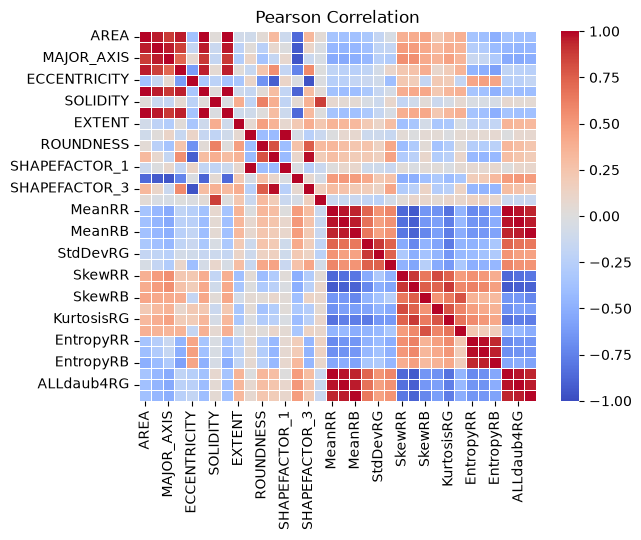

In [10]:
corr_matrix = features.corr()
sns.heatmap(
    corr_matrix, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
)
plt.title('Pearson Correlation')

## Побудувати гістограми розподілу ознак

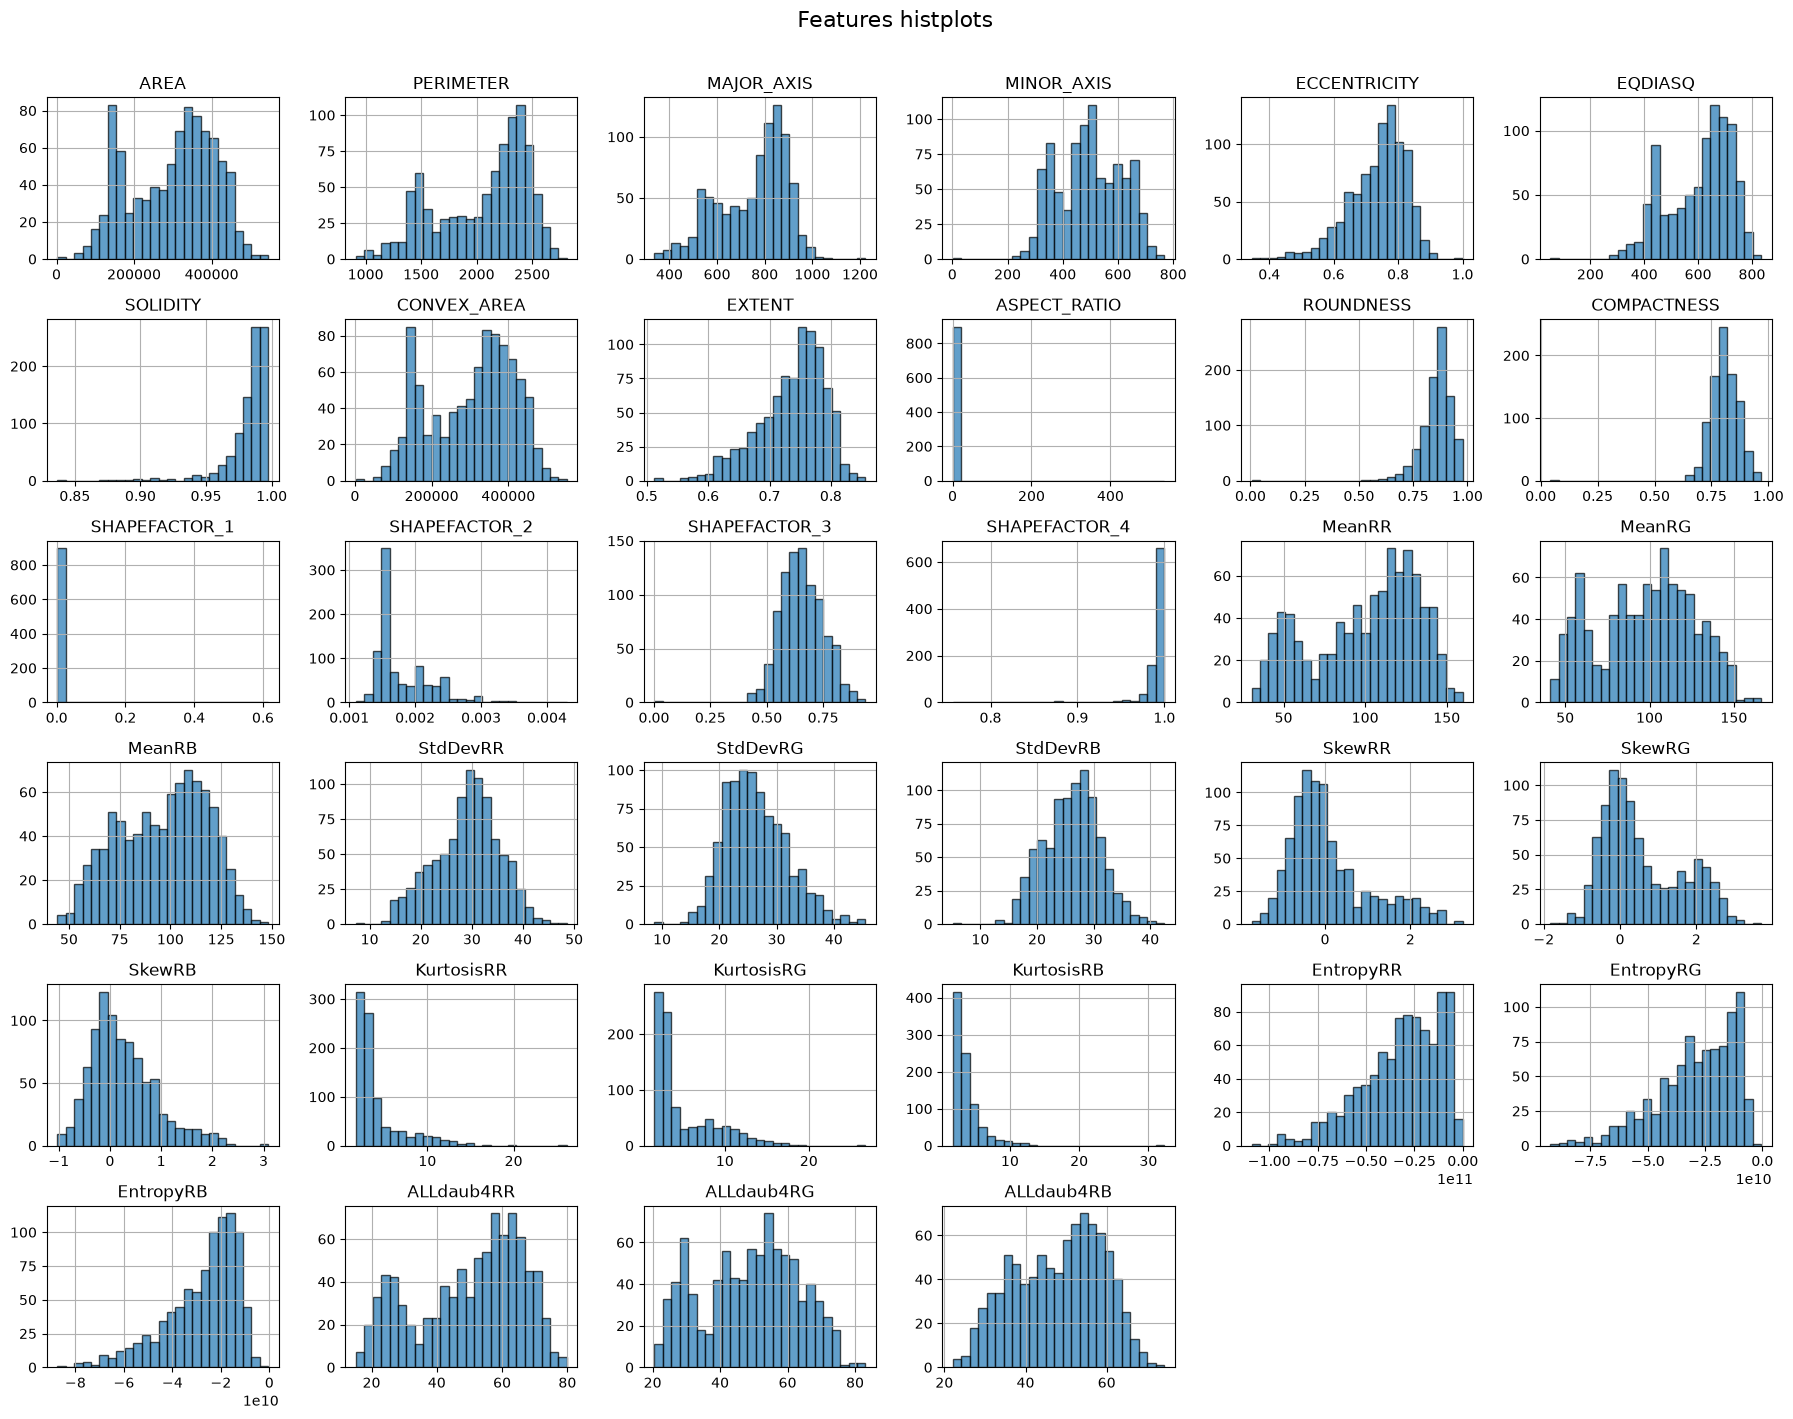

In [11]:
features.hist(figsize=(18, 14), bins=25, layout=(6, 6), edgecolor='black', alpha=0.7)
plt.suptitle("Features histplots", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

## Побудувати boxplot-и ознак відносно цільової змінної

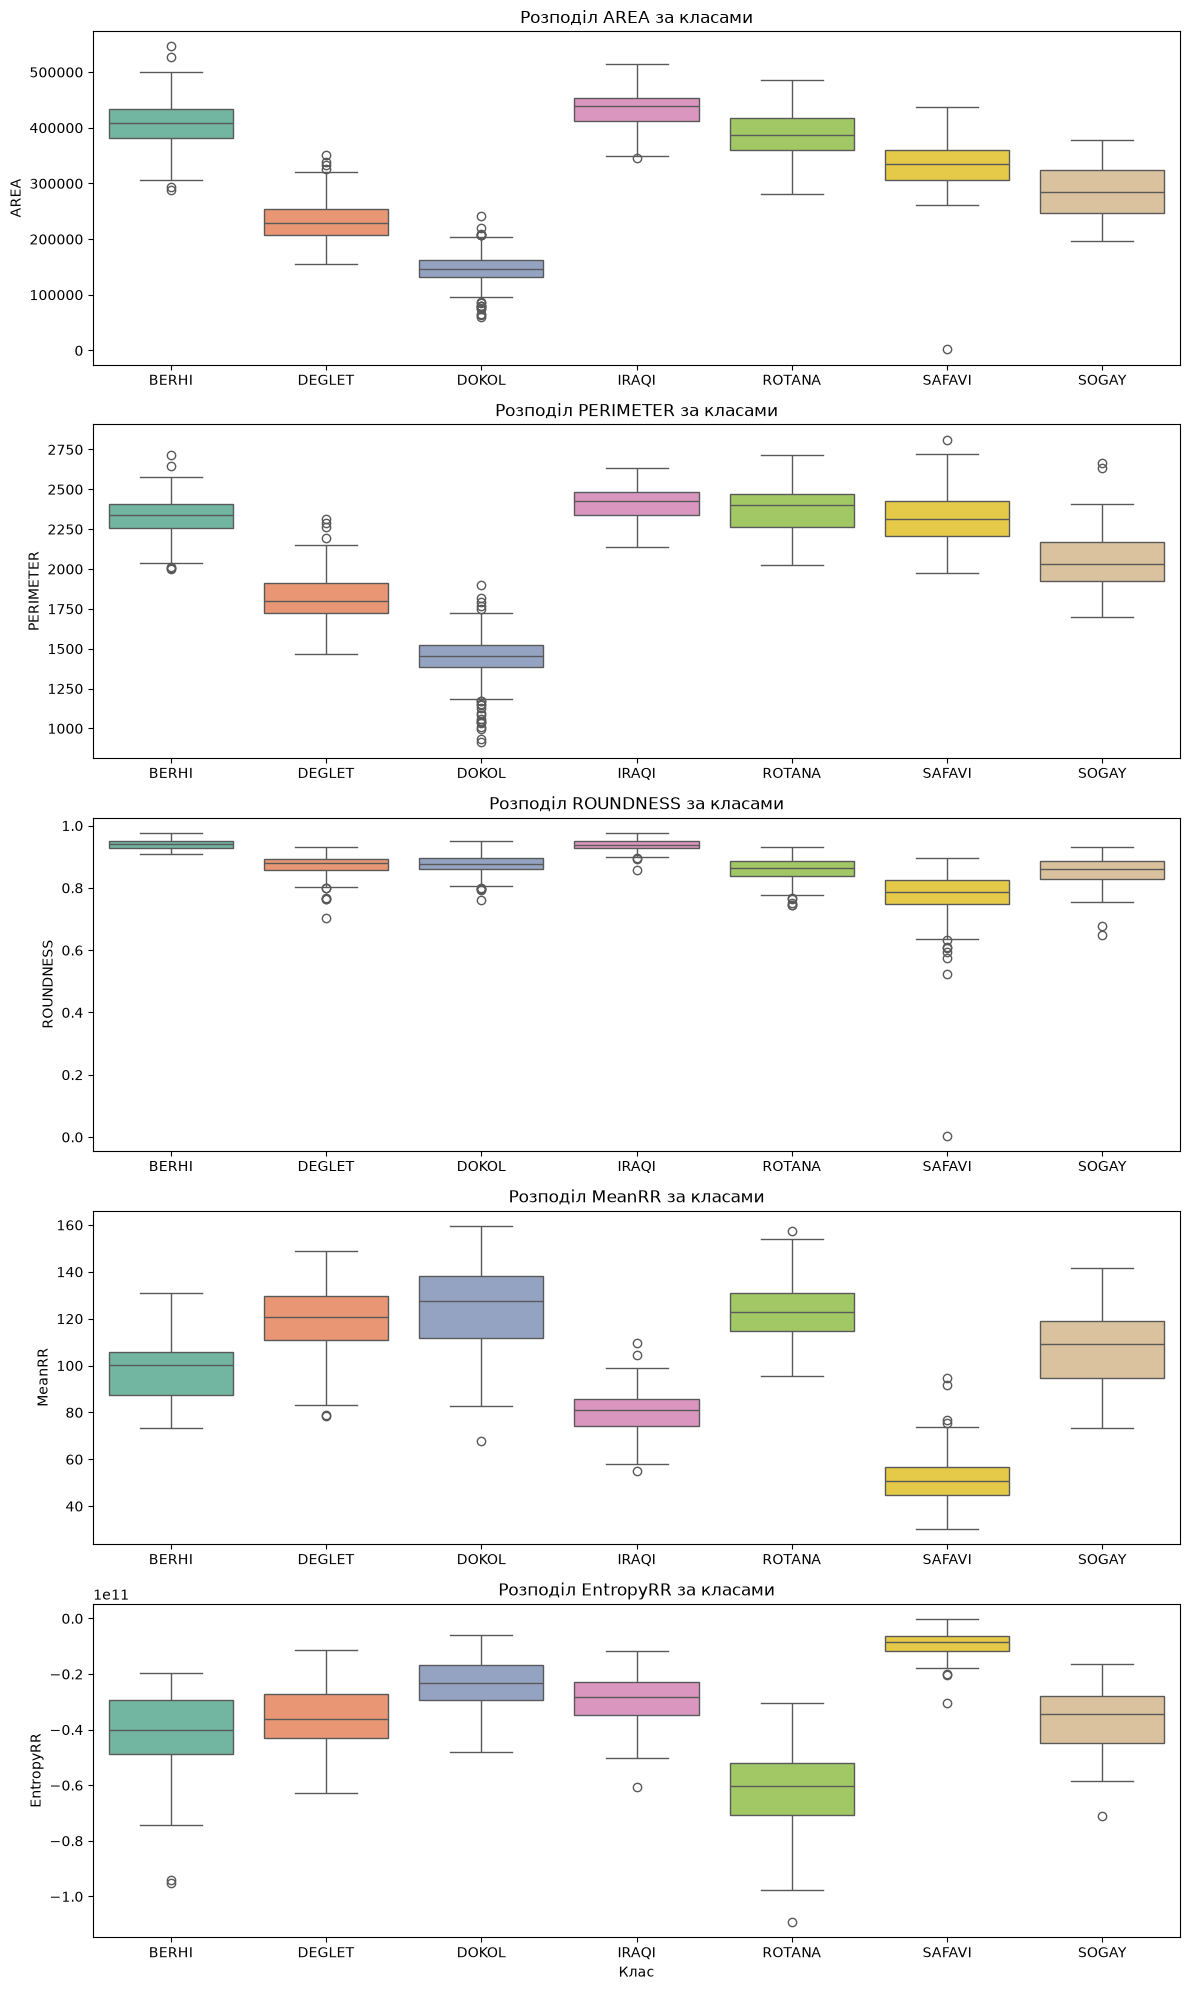

In [12]:
key_features = ['AREA', 'PERIMETER', 'ROUNDNESS', 'MeanRR', 'EntropyRR']

fig, axes = plt.subplots(nrows=len(key_features), ncols=1, figsize=(12, 4 * len(key_features)))

for ax, feat in zip(axes, key_features):
    sns.boxplot(data=raw_data, x='Class', y=feat, ax=ax, palette='Set2', hue='Class', legend=False)
    ax.set_title(f"Розподіл {feat} за класами")
    ax.set_xlabel("")

plt.xlabel("Клас")
plt.tight_layout()
plt.show()

## Коротко прокоментувати отримані візуалізації

# 4) Підготовка даних до навчання: розділити дані на training та test вибірки; виконати масштабування/нормалізацію ознак для алгоритмів, для яких це необхідно.
1. Розділити дані на training та test вибірки;
2. Виконати масштабування/нормалізацію ознак для алгоритмів, для яких це необхідно

## Розділити дані на training та test вибірки

## Виконати масштабування/нормалізацію ознак для алгоритмів, для яких це необхідно

# 5) Навчання моделей - навчити наступні класифікатори: k-Nearest Neighbors (kNN), Decision Tree, Support Vector Machine (SVM), Random Forest, AdaBoost
1. k-Nearest Neighbors (kNN);
2. Decision Tree;
3. Support Vector Machine (SVM);
4. Random Forest;
5. AdaBoost

## k-Nearest Neighbors (kNN)

## Decision Tree

## Support Vector Machine (SVM)

## Random Forest

## AdaBoost

# 6) Підбір гіперпараметрів: для kNN підібрати оптимальне значення n_neighbors, для SVM за допомогою GridSearchCV підібрати оптимальні значення C та gamma. За бажанням можна дослідити вплив гіперпараметрів і для інших моделей.
1. Для kNN підібрати оптимальне значення n_neighbors;
2. Для SVM за допомогою GridSearchCV підібрати оптимальні значення C та gamma;
3. За бажанням можна дослідити вплив гіперпараметрів і для інших моделей

## Для kNN підібрати оптимальне значення n_neighbors

## Для SVM за допомогою GridSearchCV підібрати оптимальні значення C та gamma

## За бажанням можна дослідити вплив гіперпараметрів і для інших моделей

# 7) Порівняння та оцінювання моделей
Порівняти результати всіх навчених класифікаторів та визначити найкращу модель для обраного датасета.
Для моделей вивести та проаналізувати:

    sklearn.metrics.classification_report
    sklearn.metrics.confusion_matrix

Зробити короткий висновок: яка модель показала найкращий результат і чому, на вашу думку, вона краще підходить для обраних даних.

## Порівняти результати всіх навчених класифікаторів та визначити найкращу модель для обраного датасета

## Для моделей вивести та проаналізувати sklearn.metrics.classification_report, sklearn.metrics.confusion_matrix

## Зробити короткий висновок: яка модель показала найкращий результат і чому, на вашу думку, вона краще підходить для обраних даних.